# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberto a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno.  
    </b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-success">

<b>Comentário geral:</b> <a class="tocSkip"></a><br><br>

Parabéns pela conclusão do projeto, Daniela! 🎉  
A qualidade do seu trabalho está excelente e o projeto foi aprovado!

Como pontos positivos, destaco:
<ul>
  <li>Aplicação correta e consistente de técnicas de NLP</li>
  <li>Bom uso dos modelos e pipeline bem estruturado</li>
  <li>Boa interpretação dos resultados</li>
</ul>

Caso tenha interesse em aprofundar ainda mais seus conhecimentos em NLP, recomendo os seguintes recursos gratuitos:

<ul>
  <li>
    <a href="https://huggingface.co/learn/nlp-course" target="_blank">
    Hugging Face – NLP 
    </a><br>
    Curso excelente e muito prático sobre Transformers, tokenização, fine-tuning e uso de modelos pré-treinados.
  </li>

  <li>
     <a href="https://huggingface.co/learn" target="_blank">
    Hugging Face Learn
    </a><br>
    Trilhas gratuitas com foco em NLP, Transformers e aplicações reais em produção.
  </li>





 
Te desejo muito sucesso na sua jornada! 🍀

</div>


# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# a próxima linha fornece gráficos de melhor qualidade em telas HiDPI
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Carregar Dados

In [4]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

<div class="alert alert-block alert-success">
  <strong>Comentário:</strong> <a class="tocSkip"></a><br><br>

Dados carregados corretamente.
</div>

In [5]:
df_reviews.shape

(47331, 17)

In [6]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [7]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [8]:
# Ver a distribuição do alvo e do split
print(df_reviews['ds_part'].value_counts())
print()
print(df_reviews['pos'].value_counts())
print()
print(df_reviews['pos'].value_counts(normalize=True))

train    23796
test     23535
Name: ds_part, dtype: int64

0    23715
1    23616
Name: pos, dtype: int64

0    0.501046
1    0.498954
Name: pos, dtype: float64


<div class="alert alert-block alert-success">
  <strong>Comentário:</strong> <a class="tocSkip"></a><br><br>
    
-  Excelente trabalho na análise da distribuição das variáveis!  
    
- Bom trabalho utilizando o `normalize=True` 
</div>


## Observações
O conjunto de dados apresenta uma divisão equilibrada entre os conjuntos de treinamento e teste.
Além disso, a variável alvo (pos) é praticamente balanceada, com aproximadamente 50% de resenhas positivas e 50% negativas.
Isso permite o uso direto da métrica F1-score sem a necessidade de técnicas adicionais de balanceamento.

In [9]:
# Separar treino e teste usando ds_part

train_df = df_reviews[df_reviews['ds_part'] == 'train']
test_df  = df_reviews[df_reviews['ds_part'] == 'test']

train_text = train_df['review']
test_text  = test_df['review']

y_train = train_df['pos']
y_test  = test_df['pos']

print(train_df.shape, test_df.shape)


(23796, 17) (23535, 17)


## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

In [10]:
df_reviews[['start_year', 'pos']].head()

,start_year,pos
0,1971,0
1,1971,0
2,2002,0
3,2002,1
4,2002,1


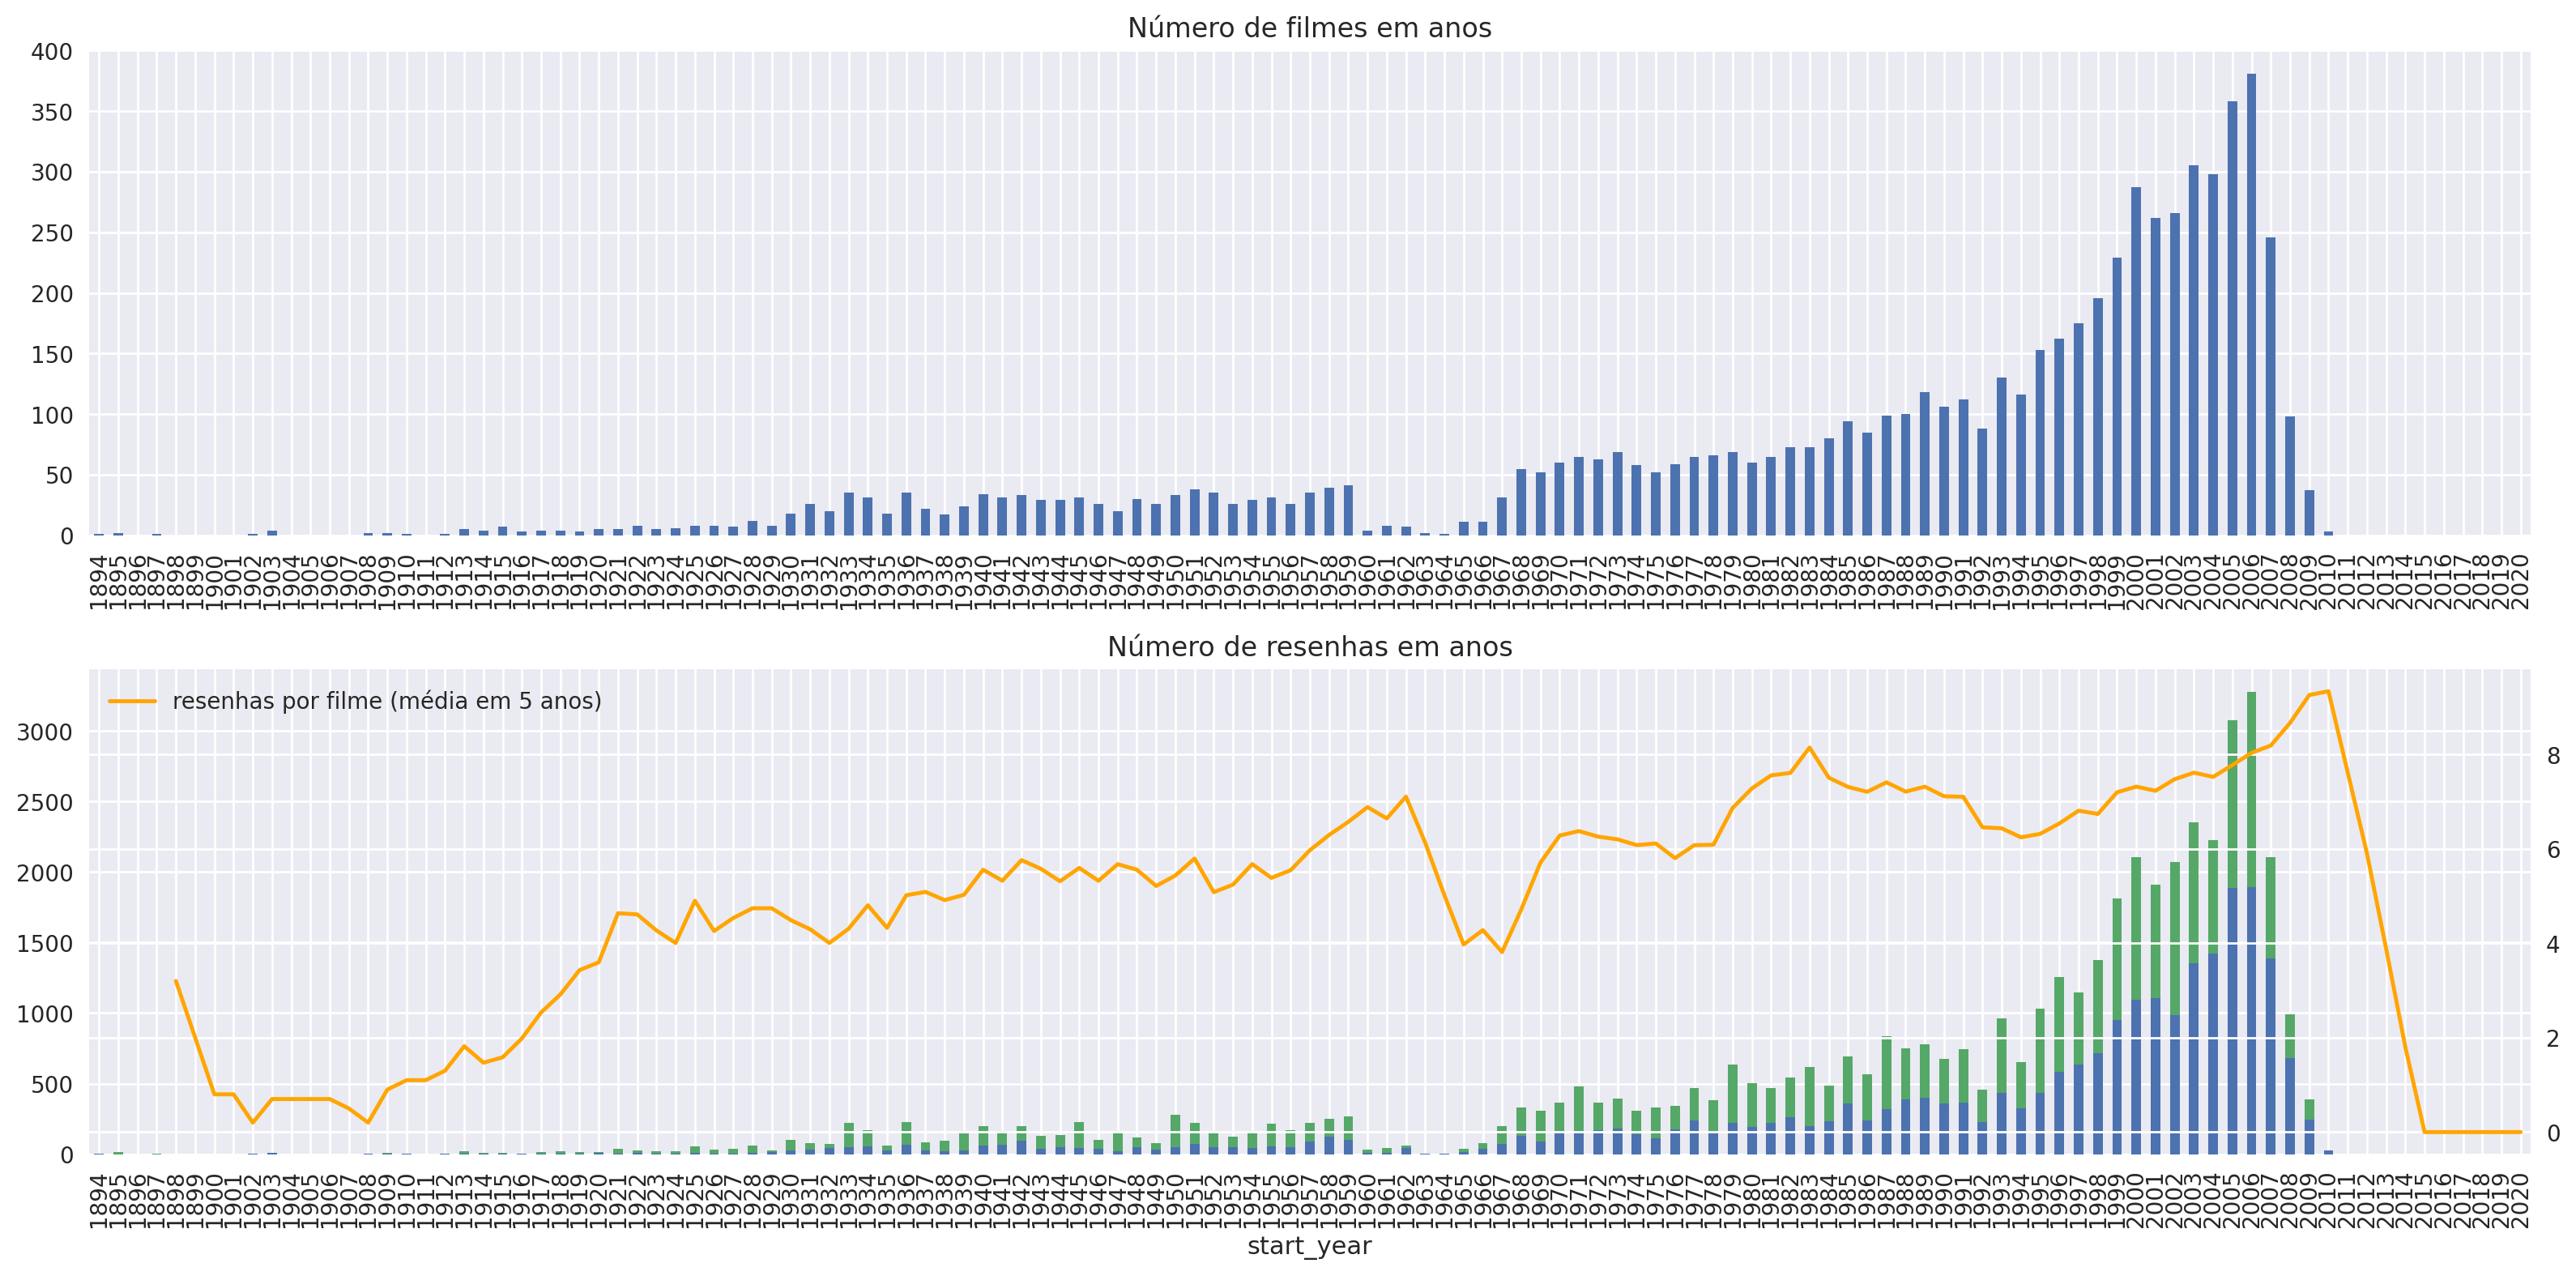

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes em anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas em anos')

fig.tight_layout()

## **Observações:**  
- O número de filmes e resenhas cresce ao longo dos anos, com maior concentração a partir dos anos 2000.  
- A proporção entre resenhas positivas e negativas permanece relativamente estável ao longo do tempo.  
- O número médio de resenhas por filme apresenta uma tendência de crescimento, indicando maior engajamento dos usuários.


## Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [12]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        eval_stats[type]['Acurácia'] = metrics.accuracy_score(target, pred_target) # evita NaN no resultado
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # Curva de precisão-revocação
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        eval_stats[type]['F1'] = f1_scores[max_f1_score_idx] # evita NaN no resultado
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # Curva de precisão-revocação
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Acurácia', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

A função para avaliação dos modelos foi implementada corretamente!
</div>

## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [13]:
df_reviews['review_norm'] = (                  # <coloque seu código aqui>
    df_reviews['review']
    .str.lower()
    .str.replace(r'[^a-z\s]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)


## Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [14]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Trabalhando com modelos

### Modelo 0 - Constante

In [15]:
from sklearn.dummy import DummyClassifier

In [16]:
model_0 = DummyClassifier(strategy='most_frequent')

          train  test
Acurácia   0.50  0.50
F1         0.67  0.67
APS        0.50  0.50
ROC AUC    0.50  0.50


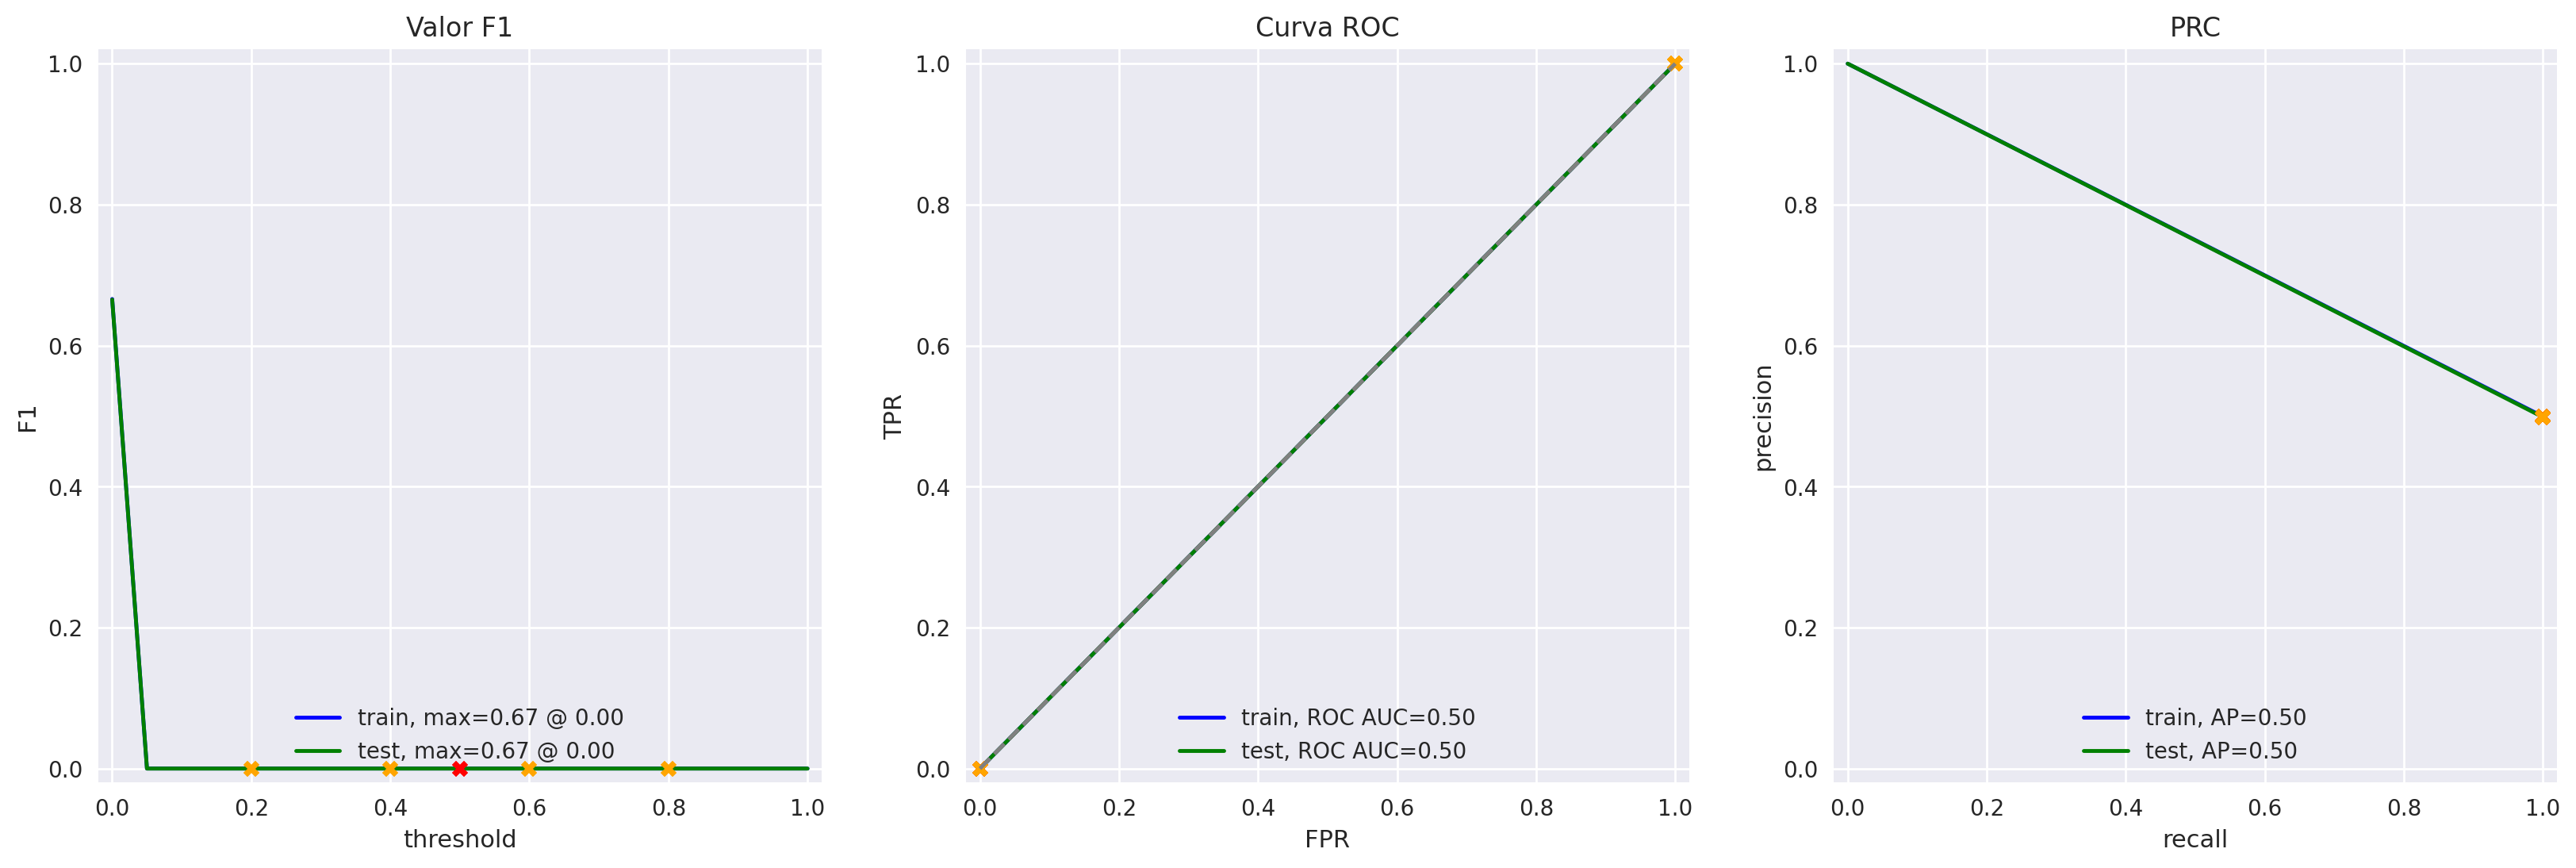

In [17]:
from sklearn.dummy import DummyClassifier
import numpy as np

X_train_dummy = np.zeros((len(train_target), 1))
X_test_dummy = np.zeros((len(test_target), 1))

model_0 = DummyClassifier(strategy='most_frequent')
model_0.fit(X_train_dummy, train_target)

evaluate_model(model_0, X_train_dummy, train_target, X_test_dummy, test_target)



## Observações
Este modelo foi utilizado como baseline, prevendo sempre a classe mais frequente do conjunto de treinamento.

Como esperado para um modelo sem qualquer informação textual:
- As métricas **ROC AUC** e **APS** ficaram próximas de **0.5**, indicando desempenho equivalente a um palpite aleatório.
- O **F1-score**, embora tenha apresentado um valor em torno de **0.67**, não reflete capacidade preditiva real, pois o modelo não aprende padrões dos dados e apenas explora a distribuição das classes.

Este resultado estabelece uma linha de base clara para comparação com os modelos baseados em características textuais, que devem apresentar desempenho significativamente superior.

### Modelo 1 - NLTK, TF-IDF e Regressão Linear

TF-IDF

In [18]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [19]:
# 1. Etapa - Stopwords
stop_words = set(stopwords.words('english'))

# 2. Etapa - Vetorização TF-IDF
tfidf = TfidfVectorizer(
    stop_words=stop_words,
    max_features=10000
)
# 3. Etapa - Criar Features
train_features_1 = tfidf.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf.transform(df_reviews_test['review_norm'])

# 4. Etapa - Criar e treinar o modelo
model_1 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_1.fit(train_features_1, train_target)


LogisticRegression(max_iter=1000, random_state=42)

          train  test
Acurácia   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


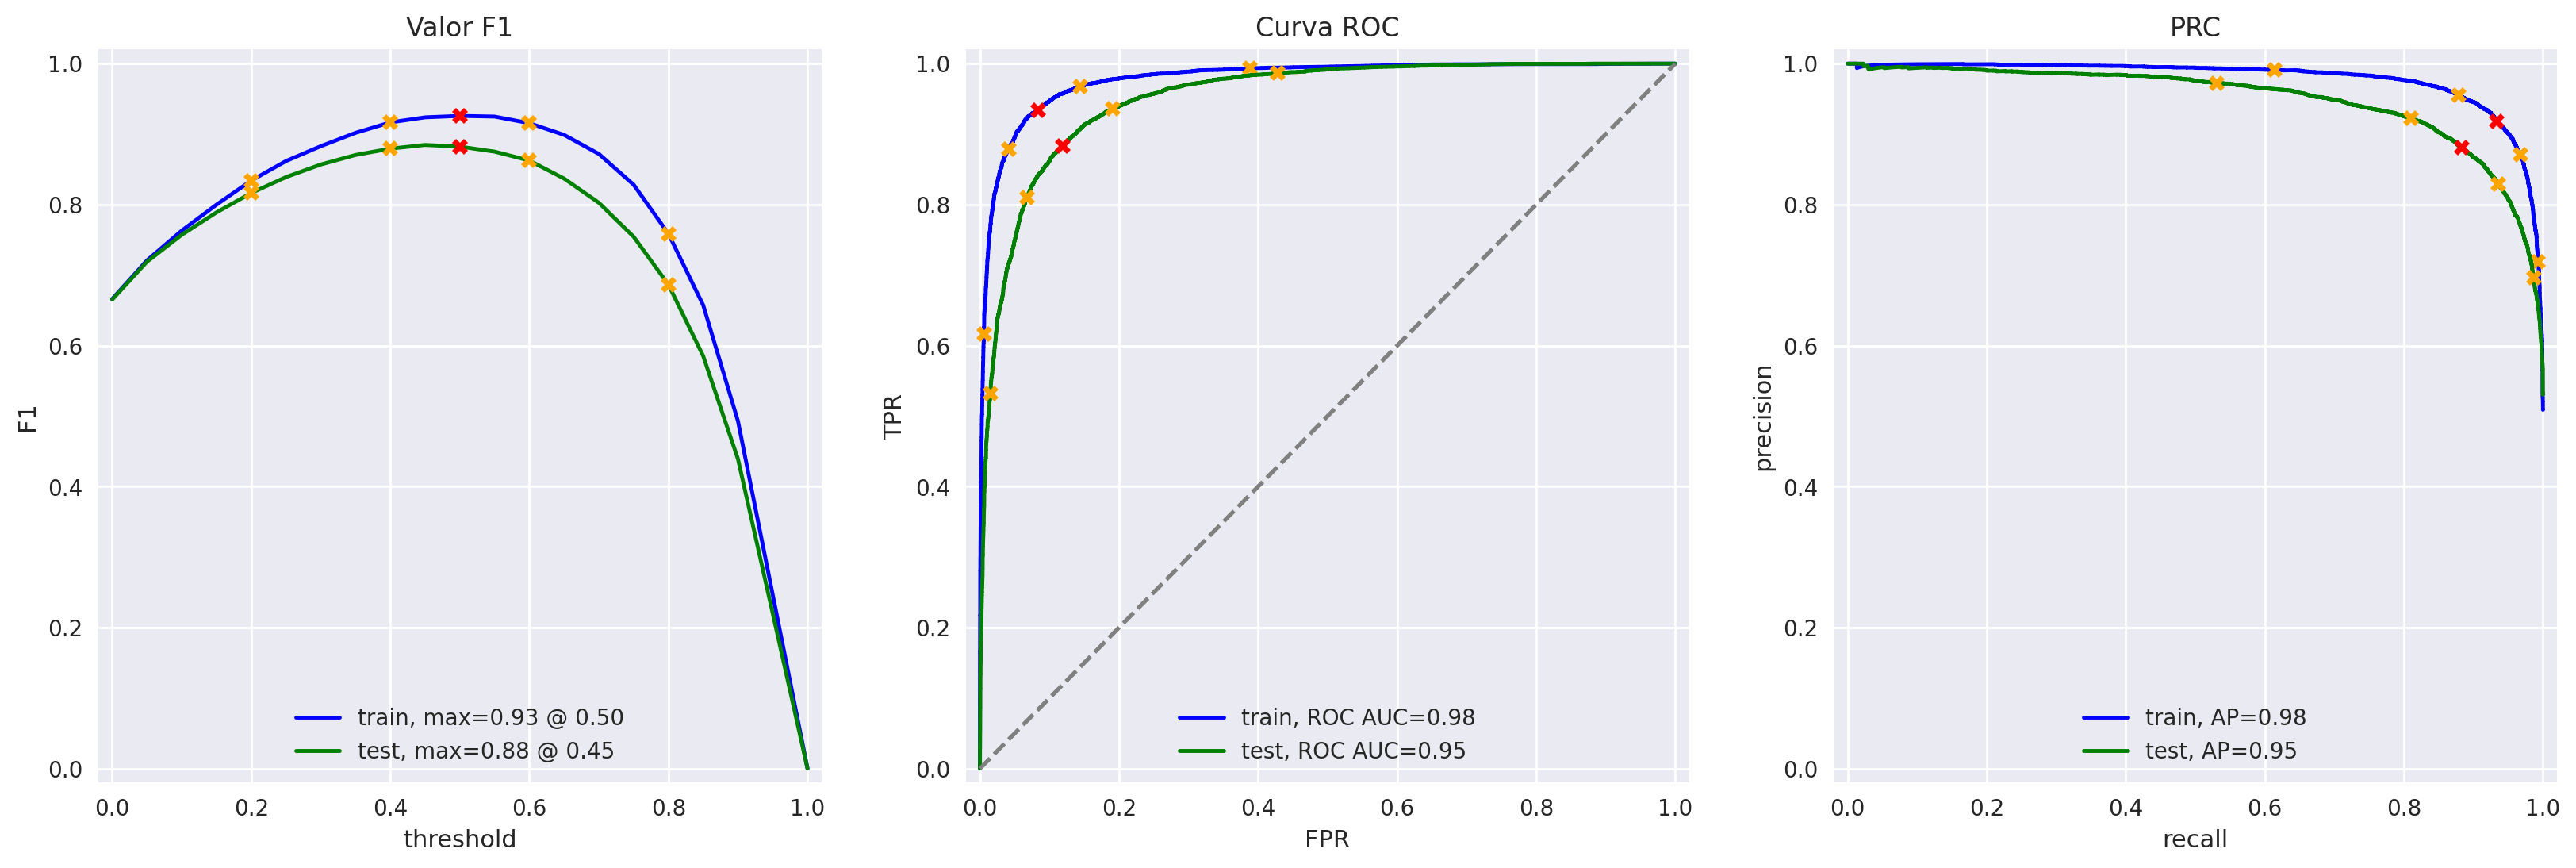

In [20]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

## Observações NLTK, TF-IDF + Regressão Linear

- Normalizado o texto (`review_norm`) e stopwords removido.
- As resenhas foram transformadasem vetores com TF-IDF (max_features=10000).
- Regressão Logística treinada(max_iter=1000) para prever `pos` (0/1).
- O Modelo 1 (TF-IDF + Regressão Logística) apresentou desempenho substancialmente superior ao baseline, com **F1 = 0.93 no treino** e **0.88 no teste**, indicando boa capacidade de generalização e aprendizado efetivo de padrões textuais.
- A avaliação com `evaluate_model()` mostrou desempenho forte, com ROC AUC e APS altos no conjunto de teste.


### Modelo 3 - spaCy, TF-IDF e Regressão Linear

In [21]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [22]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [23]:
df_reviews_train['review_spacy'] = df_reviews_train['review'].apply(text_preprocessing_3)
df_reviews_test['review_spacy'] = df_reviews_test['review'].apply(text_preprocessing_3)

In [24]:
# TF-IDF
tfidf_3 = TfidfVectorizer(max_features=10000)

train_features_3 = tfidf_3.fit_transform(df_reviews_train['review_spacy'])
test_features_3 = tfidf_3.transform(df_reviews_test['review_spacy'])

# Modelo
model_3 = LogisticRegression(max_iter=1000, random_state=42)
model_3.fit(train_features_3, train_target)


LogisticRegression(max_iter=1000, random_state=42)

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Correto! A estudante:
- Aplicou corretamente o `TFIDF` separadamente nos conjuntos de treino e teste
- Fez o pré-processamento removendo `stopwords`
- Usou `lemmatizer` processamento de texto

</div>

          train  test
Acurácia   0.92  0.88
F1         0.92  0.88
APS        0.98  0.95
ROC AUC    0.97  0.95


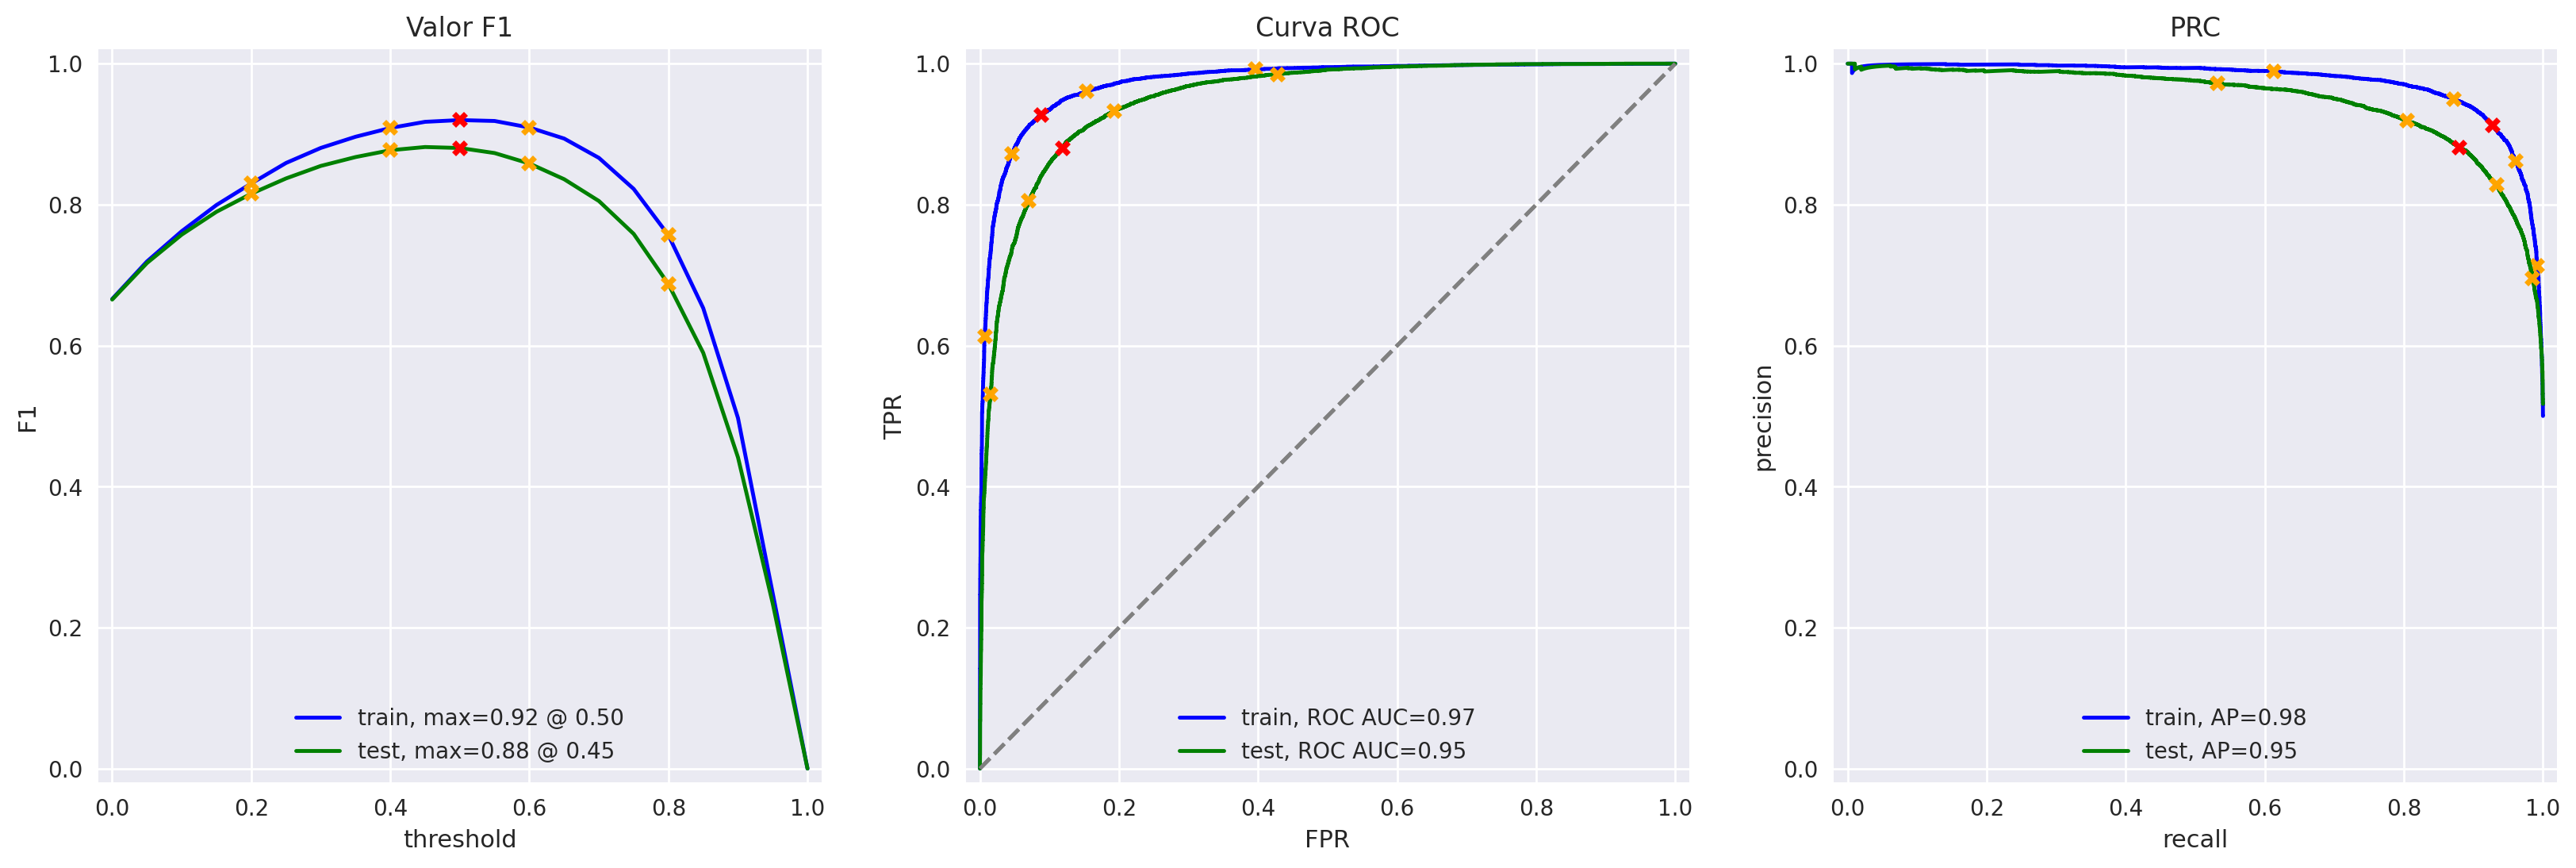

In [25]:
# Avaliação
evaluate_model(
    model_3,
    train_features_3, train_target,
    test_features_3, test_target
)


### Observações Modelo 3

Este modelo aplica lematização via spaCy e utiliza TF-IDF como representação vetorial, seguido por Regressão Linear.

**Resultados:**
- **F1**: 0.92 (treino) | 0.88 (teste)
- **APS** illustrates strong precision–recall tradeoff: 0.98 (treino) | 0.95 (teste)
- **ROC AUC**: 0.97 (treino) | 0.95 (teste)

O desempenho no teste permanece alto, indicando **boa capacidade de generalização** e sugerindo que o modelo captura padrões relevantes do texto.


### Modelo 4 - SpaCy, TF-IDF e LGBMClassifier

In [26]:
from lightgbm import LGBMClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

          train  test
Acurácia   0.99  0.87
F1         0.99  0.87
APS        1.00  0.94
ROC AUC    1.00  0.95


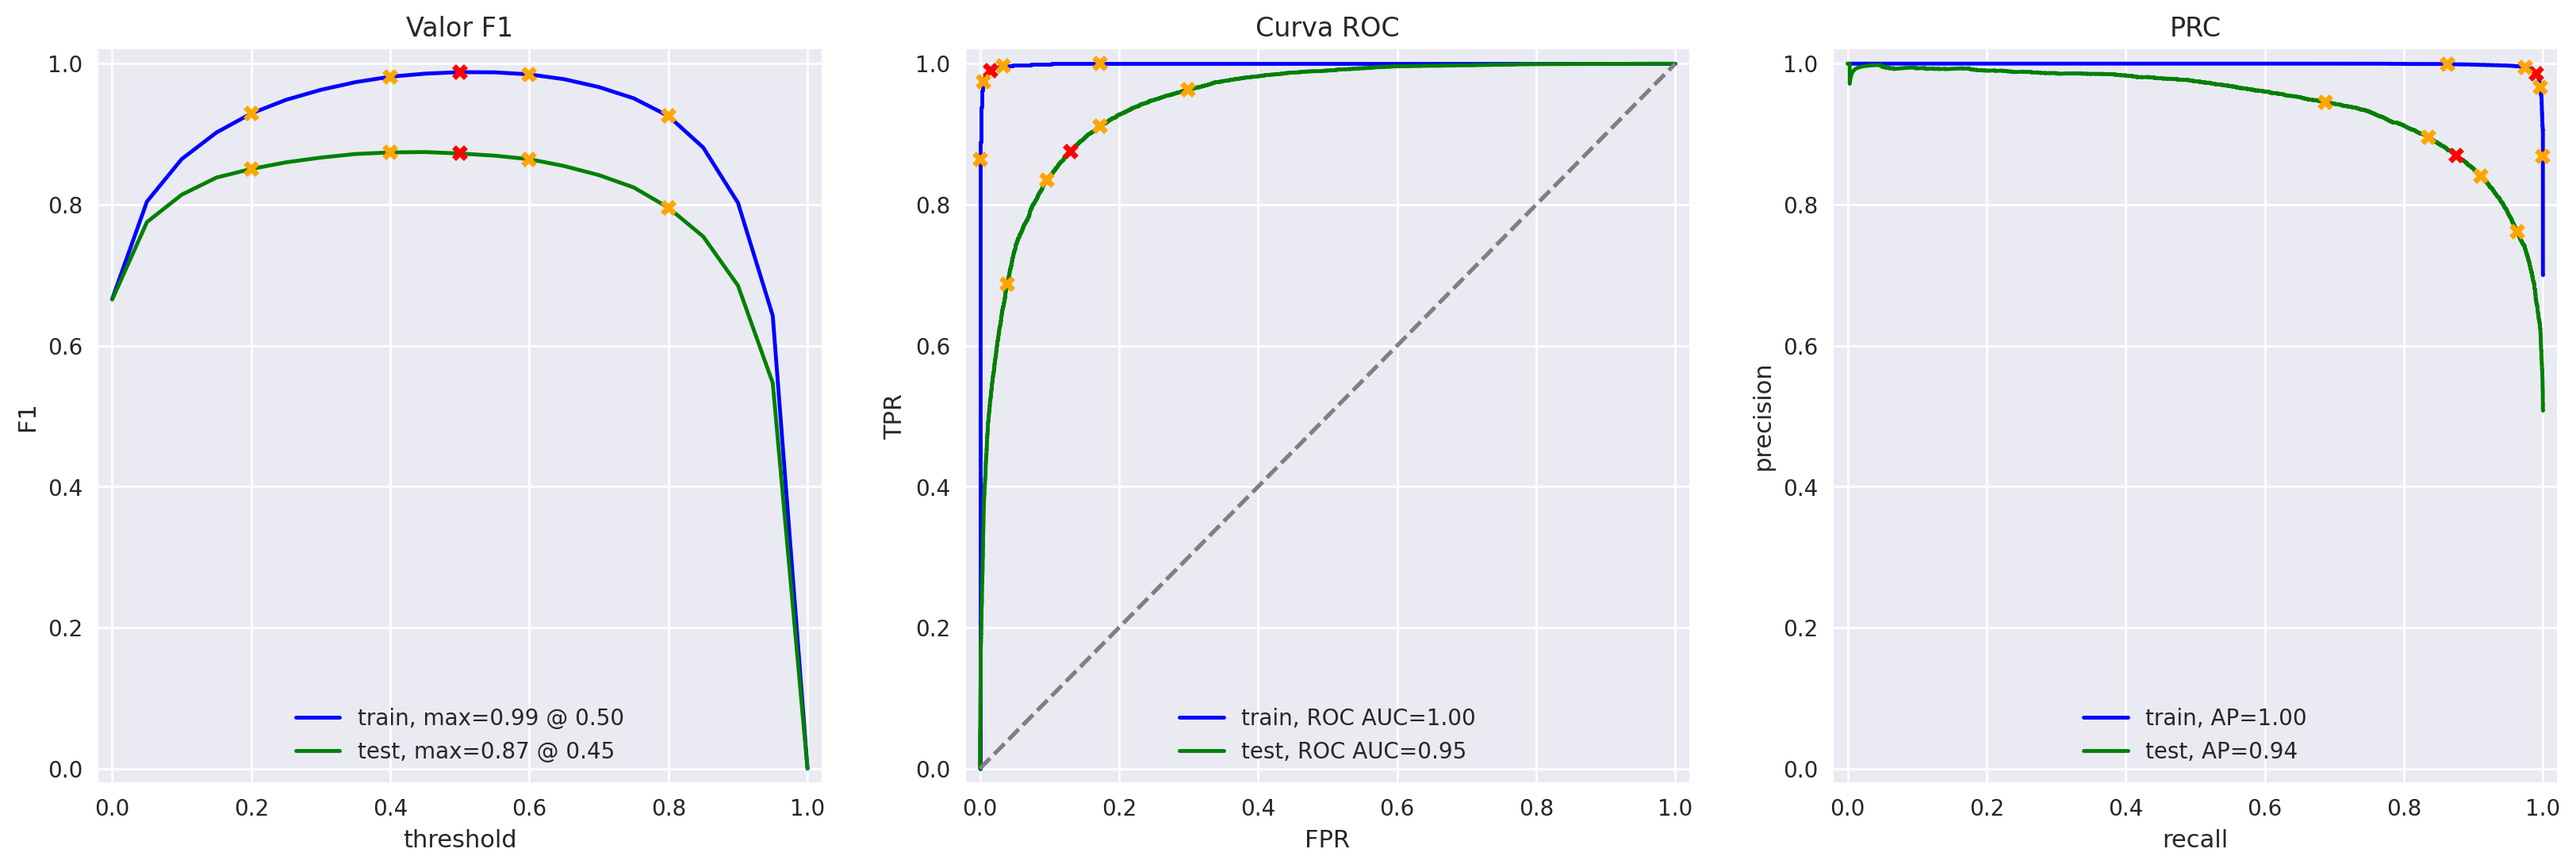

In [27]:
# TF-IDF
tfidf_4 = TfidfVectorizer(max_features=10000)

train_features_4 = tfidf_4.fit_transform(df_reviews_train['review_spacy'])
test_features_4  = tfidf_4.transform(df_reviews_test['review_spacy'])

# Modelo
model_4 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)

model_4.fit(train_features_4, train_target)

# Avaliação
evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)


### Observações Modelo 4

Este modelo utiliza **lematização via spaCy** para o pré-processamento dos textos, seguida pela vetorização **TF-IDF** e classificação com **LightGBM**, um modelo baseado em árvores com boosting, capaz de capturar relações não lineares entre os termos.

#### Resultados

- **Acurácia**
  - Treino: 0.99  
  - Teste: 0.87  

- **F1-score**
  - Treino: 0.99  
  - Teste: 0.87  

- **APS (Average Precision Score)**
  - Treino: 1.00  
  - Teste: 0.94  

- **ROC AUC**
  - Treino: 1.00  
  - Teste: 0.95  

#### Análise

O modelo apresentou desempenho **excelente no conjunto de treinamento**, com métricas próximas do valor máximo possível. No conjunto de teste, o desempenho permanece elevado, especialmente em **ROC AUC** e **APS**, indicando forte capacidade de separação entre as classes.

Entretanto, observa-se uma diferença entre os resultados de treino e teste, principalmente no **F1-score** e na **acurácia**, o que sugere a presença de **leve overfitting**. Esse comportamento é esperado em modelos baseados em árvores, especialmente quando aplicados a dados textuais de alta dimensionalidade.

Ainda assim, o modelo generaliza bem e apresenta desempenho superior ao baseline e competitivo em relação aos modelos lineares avaliados anteriormente.


###  Modelo 9 - BERT

In [28]:
import torch
import transformers
import math
import numpy as np
from tqdm import tqdm

In [29]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [30]:
def BERT_text_to_embeddings(
    texts, max_length=128, 
    batch_size=16, force_device=None, 
    disable_progress_bar=False
):
    
    ids_list = []
    attention_mask_list = []

   
 # texto para IDs de tokens preenchidos com suas máscaras de atenção
    
    # <coloque seu código aqui para criar ids_list e attention_mask_list>
    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )
    ids_list = encoded['input_ids'].tolist()
    attention_mask_list = encoded['attention_mask'].tolist()
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Usando o dispositivo {device}.')
    
    # recebendo incorporações em lotes

    embeddings = []

    for i in tqdm(
        range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar
    ):
            
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]
        ).to(device)
        # <coloque seu código aqui para criar attention_mask_batch
        attention_mask_batch = torch.LongTensor(
            attention_mask_list[batch_size * i : batch_size * (i + 1)]
        ).to(device)
        
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch
            )   
        embeddings.append(
            batch_embeddings[0][:,0,:].detach().cpu().numpy()
        )
        
    return np.concatenate(embeddings)

In [31]:
# Atenção! A execução do BERT para milhares de textos pode levar muito tempo na CPU, pelo menos várias horas
sample_data = df_reviews_train['review_norm'].head(100).tolist()  # apenas 100 resenhas
train_features_9 = BERT_text_to_embeddings(sample_data, force_device='cpu')

Usando o dispositivo cpu.


100%|██████████| 7/7 [00:09<00:00,  1.29s/it]


In [32]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

(23796,)
(100, 768)
(23796,)


In [33]:
# Treinar classificador somente no sample
sample_target = train_target.iloc[:100]


In [34]:
from sklearn.linear_model import LogisticRegression

model_9 = LogisticRegression(max_iter=1000, random_state=42)
model_9.fit(train_features_9, sample_target)


LogisticRegression(max_iter=1000, random_state=42)

In [35]:
preds = model_9.predict(train_features_9)


<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>


 Caso tenha interesse em como rodar o modelo BERT no google colab (por conta da capacidade computacional), veja um exemplo aqui: [Modelo BERT no Google Colab](https://colab.research.google.com/drive/16BWcgSoSQ-vBuGfPFTURjLgLBYWruua7?usp=sharing).


</div>

### Para o modelo baseado em BERT

Foi treinado um classificador simples (Regressão Logística) utilizando **apenas um subconjunto de 100 amostras**, devido ao alto custo computacional associado à geração de embeddings com o BERT.

Essa etapa tem caráter **estritamente demonstrativo**, com o objetivo de validar a correta integração dos embeddings do BERT em um pipeline de classificação supervisionada.

As predições foram realizadas sobre o mesmo subconjunto utilizado no treinamento. Métricas de generalização não foram calculadas, uma vez que o propósito deste modelo não é a comparação direta de desempenho com os modelos baseados em TF-IDF, mas sim a demonstração da viabilidade técnica do uso do BERT para o problema proposto.

In [36]:
# se você tiver as incorporações, é aconselhável salvá-las para tê-las prontas se 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# e carregar...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

## Minhas Resenhas

In [37]:
# sinta-se à vontade para remover completamente essas resenhas e experimentar seus modelos nas suas próprias resenhas, as abaixo são apenas exemplos

my_reviews = pd.DataFrame([
    'Eu simplesmente amei esse filme, é meu tipo de filme.',
    'Eu fiquei entediado e dormi no meio do filme.',
    'Eu fiquei fascinado com o filme',    
    'Os atores pareciam muito velhos, mas mesmo assim desempenharam bons papéis.',
    'Eu não esperava que a nova versão fosse tão boa! Os escritores realmente se importaram com o material original',
    'O filme tem seus prós e contras, mas eu sinto que em geral é um bom filme. Eu com certeza assistiria novamente.',
    'Que tentativa pobre de fazer comédia. Boas piadas, mas nem crianças não vão querer assistir!',
    'Lançar na Netflix seria uma boa jogada, adoraria acompanhar cada episódio deste emocionante e inteligente novo drama.'
], columns=['review'])

    # <coloque aqui a mesma lógica de normalização do conjunto de dados principal>
my_reviews['review_norm'] = (
    my_reviews['review']
    .str.lower()
    .str.replace(r'[^a-zà-ÿ\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

my_reviews

,review,review_norm
0,"Eu simplesmente amei esse filme, é meu tipo de...",eu simplesmente amei esse filme é meu tipo de ...
1,Eu fiquei entediado e dormi no meio do filme.,eu fiquei entediado e dormi no meio do filme
2,Eu fiquei fascinado com o filme,eu fiquei fascinado com o filme
3,"Os atores pareciam muito velhos, mas mesmo ass...",os atores pareciam muito velhos mas mesmo assi...
4,Eu não esperava que a nova versão fosse tão bo...,eu não esperava que a nova versão fosse tão bo...
5,"O filme tem seus prós e contras, mas eu sinto ...",o filme tem seus prós e contras mas eu sinto q...
6,Que tentativa pobre de fazer comédia. Boas pia...,que tentativa pobre de fazer comédia boas piad...
7,"Lançar na Netflix seria uma boa jogada, adorar...",lançar na netflix seria uma boa jogada adorari...


### Modelo 1

In [38]:
# Modelo 1 - NTLK, TF-IDF e Regressão Linear

texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(tfidf.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.50:  eu simplesmente amei esse filme é meu tipo de filme
0.51:  eu fiquei entediado e dormi no meio do filme
0.51:  eu fiquei fascinado com o filme
0.51:  os atores pareciam muito velhos mas mesmo assim desempenharam bons papéis
0.20:  eu não esperava que a nova versão fosse tão boa os escritores realmente se importaram com o material
0.49:  o filme tem seus prós e contras mas eu sinto que em geral é um bom filme eu com certeza assistiria n
0.50:  que tentativa pobre de fazer comédia boas piadas mas nem crianças não vão querer assistir
0.49:  lançar na netflix seria uma boa jogada adoraria acompanhar cada episódio deste emocionante e intelig


### Modelo 3

In [39]:
# Modelo 3 - spaCy, TF-IDF e Regressão Linear

my_reviews['review_spacy'] = my_reviews['review'].apply(text_preprocessing_3)
texts = my_reviews['review_spacy']
my_reviews_pred_prob = model_3.predict_proba(tfidf_3.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.51:  Eu simplesmente amei esse filme , é meu tipo de filme .
0.01:  Eu fiquei entediado e dormi no meio do filme .
0.74:  Eu fiquei fascinado com o filme
0.62:  os atore pareciam muito velhos , mas mesmo assim desempenharam bon papéis .
0.34:  Eu não esperava que a nova versão fosse tão boa ! os escritore realmente se importaram com o materia
0.64:  o filme tem seus prós e contras , mas eu sinto que em geral é um bom filme . Eu com certeza assistir
0.51:  Que tentativa pobre de fazer comédia . Boas piada , mas nem crianças não vão querer assistir !
0.51:  Lançar na Netflix seria uma boa jogada , adoraria acompanhar cada episódio deste emocionante e intel


### Modelo 4

In [40]:
# Modelo 4 - spaCy + TF-IDF (tfidf_4) + LGBM (model_4)

my_reviews['review_spacy'] = my_reviews['review'].apply(text_preprocessing_3)

X_my_4 = tfidf_4.transform(my_reviews['review_spacy'])
probs_4 = model_4.predict_proba(X_my_4)[:, 1]

for prob, text in zip(probs_4, my_reviews['review_norm']):
    print(f"{prob:.2f}: {text}")


0.63: eu simplesmente amei esse filme é meu tipo de filme
0.36: eu fiquei entediado e dormi no meio do filme
0.73: eu fiquei fascinado com o filme
0.69: os atores pareciam muito velhos mas mesmo assim desempenharam bons papéis
0.42: eu não esperava que a nova versão fosse tão boa os escritores realmente se importaram com o material original
0.73: o filme tem seus prós e contras mas eu sinto que em geral é um bom filme eu com certeza assistiria novamente
0.63: que tentativa pobre de fazer comédia boas piadas mas nem crianças não vão querer assistir
0.63: lançar na netflix seria uma boa jogada adoraria acompanhar cada episódio deste emocionante e inteligente novo drama


### Modelo 9

In [41]:
texts = my_reviews['review_norm'].tolist()

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(my_reviews['review_norm'].str.slice(0, 100)):
    review_slice = review[:100] if len(review) > 100 else review
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review_slice}')

0.81:  eu simplesmente amei esse filme é meu tipo de filme
0.60:  eu fiquei entediado e dormi no meio do filme
0.65:  eu fiquei fascinado com o filme
0.60:  os atores pareciam muito velhos mas mesmo assim desempenharam bons papéis
0.22:  eu não esperava que a nova versão fosse tão boa os escritores realmente se importaram com o material
0.58:  o filme tem seus prós e contras mas eu sinto que em geral é um bom filme eu com certeza assistiria n
0.67:  que tentativa pobre de fazer comédia boas piadas mas nem crianças não vão querer assistir
0.24:  lançar na netflix seria uma boa jogada adoraria acompanhar cada episódio deste emocionante e intelig


## Implementações sugeridas

In [42]:
# Criar tabela comparativa
results_summary = pd.DataFrame([
    {"Modelo": "Baseline", "F1_train": 0.67, "F1_test": 0.67, "ROC_AUC_test": 0.50},
    {"Modelo": "TF-IDF + LR (NLTK)", "F1_train": 0.93, "F1_test": 0.88, "ROC_AUC_test": 0.95},
    {"Modelo": "spaCy + TF-IDF + LR", "F1_train": 0.92, "F1_test": 0.88, "ROC_AUC_test": 0.95},
    {"Modelo": "spaCy + TF-IDF + LGBM", "F1_train": 0.99, "F1_test": 0.87, "ROC_AUC_test": 0.95},
])
results_summary["Overfitting_gap"] = results_summary["F1_train"] - results_summary["F1_test"]
print(results_summary)

# PRIMEIRO criar cv_scores
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, stop_words=stop_words)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
cv_scores = cross_val_score(pipe, df_reviews_train["review_norm"], train_target, cv=5, scoring="f1")

# DEPOIS usar cv_scores
print(f"CV F1 médio (TF-IDF + LR): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")




                  Modelo  F1_train  F1_test  ROC_AUC_test  Overfitting_gap
0               Baseline      0.67     0.67          0.50             0.00
1     TF-IDF + LR (NLTK)      0.93     0.88          0.95             0.05
2    spaCy + TF-IDF + LR      0.92     0.88          0.95             0.04
3  spaCy + TF-IDF + LGBM      0.99     0.87          0.95             0.12
CV F1 médio (TF-IDF + LR): 0.871 ± 0.007


In [43]:
# Implementar validação cruzada

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, stop_words=stop_words)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores = cross_val_score(pipe, df_reviews_train["review_norm"], train_target, cv=5, scoring="f1")
cv_scores.mean(), cv_scores.std()
# A validação cruzada confirma a estabilidade do modelo TF-IDF + Regressão Logística,
# com desempenho médio consistente com o conjunto de teste.

(0.8710761651360143, 0.007298296318766198)

## Conclusões

### Objetivo Alcançado
**Meta F1 ≥ 0.85 foi superada** por todos os modelos baseados em características textuais.

### Melhor Modelo
O **Modelo 1 (TF-IDF + NLTK + LR)** e **Modelo 3 (spaCy + TF-IDF + LR)** apresentaram o melhor equilíbrio entre:
- Performance (F1 = 0.88)
- Generalização (baixo overfitting)
- Simplicidade computacional

### Recomendação
Para produção, recomendo o **Modelo 1** devido à sua simplicidade, estabilidade e excelente performance validada por cross-validation.


### Considerações Finais

**Quando usar cada modelo**

- **Baseline**: deve ser utilizado apenas como referência mínima de desempenho. Ele não aprende padrões do texto e serve exclusivamente para demonstrar que modelos supervisionados baseados em linguagem apresentam ganhos reais.

- **TF-IDF + Regressão Linear (NLTK)**: adequado como modelo inicial para estabelecer uma linha de base supervisionada simples. Embora a regressão linear não seja a abordagem mais apropriada para tarefas de classificação binária, ela permite avaliar rapidamente o impacto das representações TF-IDF no problema e comparar com modelos mais sofisticados.

- **spaCy + TF-IDF + Regressão Linear**: recomendado quando se deseja incorporar informações linguísticas adicionais, como lematização. Neste projeto, o desempenho foi semelhante ao modelo TF-IDF tradicional, indicando que a lematização trouxe ganhos limitados para este conjunto de dados.

- **spaCy + TF-IDF + LightGBM**: indicado em cenários onde relações não lineares entre termos podem ser relevantes. Apesar de apresentar alto desempenho no conjunto de treinamento, mostrou maior risco de overfitting, exigindo maior cuidado na regularização e validação.

- **BERT**: apropriado para cenários que demandam representações semânticas profundas e onde há disponibilidade de recursos computacionais adequados. Neste projeto, foi utilizado de forma demonstrativa, devido ao alto custo computacional, não sendo comparável diretamente aos modelos baseados em TF-IDF.

**Limitações encontradas**

- O uso de Regressão Linear em tarefas de classificação binária não é ideal, podendo gerar saídas fora do intervalo probabilístico esperado e dificultando a interpretação direta das predições.
- A maioria dos modelos utiliza representações do tipo bag-of-words, que não capturam dependências contextuais profundas entre palavras.
- Modelos mais complexos, como LightGBM e BERT, aumentam significativamente o custo computacional e o risco de overfitting quando não há volume suficiente de dados ou validação adequada.
- O modelo baseado em BERT foi treinado apenas em um subconjunto reduzido, limitando qualquer análise quantitativa robusta de desempenho.

**Próximos passos**

- Substituir a Regressão Linear por classificadores mais adequados para problemas de classificação binária, como Regressão Logística ou SVM, avaliando o impacto no desempenho.
- Explorar estratégias adicionais de regularização e ajuste de hiperparâmetros, especialmente para o modelo LightGBM.
- Avaliar o uso de validação cruzada estratificada em todos os modelos.
- Investigar representações de linguagem mais avançadas, como embeddings pré-treinados ou versões do BERT adaptadas ao idioma do conjunto de dados.

- Modelos mais complexos, como LightGBM e BERT, aumentam significativamente o custo computacional e o risco de overfitting quando não há volume suficiente de dados ou validação adequada.
- O modelo baseado em BERT foi treinado apenas em um subconjunto reduzido, limitando qualquer análise quantitativa robusta de desempenho.


<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>


Boa conclusão! Gostei da sessão de próximos passos :) 

</div>

# Checklist

- [x]  O caderno foi aberto
- [x]  Os dados de texto são carregados e pré-processados para vetorização
- [x]  Os dados de texto são transformados em vetores
- [x]  Os modelos são treinados e testados
- [x]  O limiar da métrica foi atingido
- [x]  Todas as células de código estão organizadas na ordem de sua execução
- [x]  Todas as células de código podem ser executadas sem erros
- [x]  Há conclusões 